In [1]:
#!pip install pyreadr
#!pip install pot

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyreadr
from sklearn.model_selection import StratifiedKFold
import ot
import pandas as pd
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

nets = pyreadr.read_r('networks.rds')
labels = pyreadr.read_r('labels.rds')

In [3]:
df = nets[None]
df

,0,1,2,3,4,5,6,7,8,9,...,34443,34444,34445,34446,34447,34448,34449,34450,34451,34452
0,0.937964,0.036858,0.233517,0.357248,0.300294,0.072664,0.131153,0.095430,-0.006198,0.153983,...,0.185215,0.429179,0.346439,0.111311,0.347075,0.284673,0.135142,0.419904,0.235776,0.486115
1,0.122836,0.197231,-0.159027,0.100587,-0.087402,-0.066368,-0.055579,0.404727,-0.103306,0.056261,...,0.187443,0.620209,0.406304,0.381617,0.472145,0.447971,0.134374,0.205255,0.508898,0.492664
2,0.609382,0.175494,-0.024736,0.170654,0.051464,0.185128,0.184114,-0.046622,0.348225,0.265189,...,0.007055,0.189252,0.131152,0.122525,0.354497,0.190312,-0.247709,0.293514,-0.170872,0.343746
3,0.150549,-0.065422,0.246946,0.060092,0.004350,0.402564,-0.125902,0.027463,0.349015,0.171557,...,-0.050271,0.743368,0.299041,-0.069612,0.211402,0.352202,-0.040681,0.270711,0.239744,0.166712
4,0.818724,0.466267,0.460847,0.608540,0.632230,0.188454,0.303265,0.236847,0.442380,0.218805,...,0.053355,0.356244,0.081661,0.125469,-0.032464,0.291471,-0.098654,0.611725,0.204744,0.380010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,0.677140,0.321552,0.117745,0.168275,0.211885,0.099639,0.313155,0.182389,0.224607,-0.130002,...,-0.094510,0.648144,0.544748,0.145445,0.572884,0.718308,0.506452,0.704904,0.631571,0.091547
120,0.551664,0.178585,0.051788,-0.264080,-0.038901,0.025136,0.188339,-0.131339,0.492654,-0.280235,...,0.156233,0.488505,-0.069349,0.008380,0.019600,0.146450,-0.144245,0.292833,-0.130710,0.055620
121,0.603361,0.581785,0.363042,0.190121,0.184959,0.046118,0.057942,0.106672,0.346750,0.056851,...,-0.204461,0.360031,0.565816,0.255710,0.349328,0.486091,0.039027,0.167118,-0.259183,0.173690
122,0.251397,0.441282,0.190952,0.485988,0.200581,0.364325,0.431289,0.082483,0.536304,0.200708,...,0.188570,0.147478,0.551669,0.189728,0.287138,0.172694,0.092271,-0.081608,0.316341,0.171579


In [4]:
linmat = np.array(df.iloc[102])
linmat.shape

(34453,)

In [5]:
n = 263
mat = np.zeros((n, n))
mat[np.triu_indices(n, 1)] = linmat
mat += mat.T

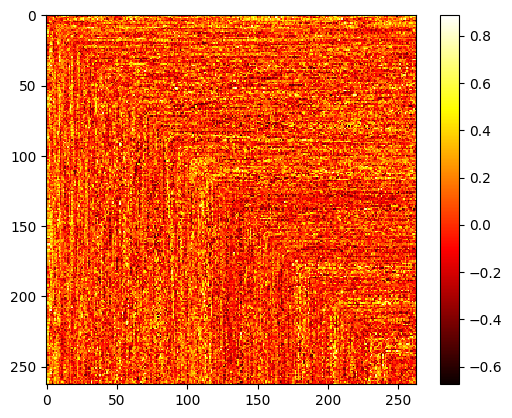

In [6]:
plt.imshow(mat,cmap='hot',interpolation='none')
plt.colorbar()

In [7]:
mat[1,6]


np.float64(-0.37829918900274)

In [8]:
# 1 denotes s, -1 denotes healthy
labels

OrderedDict([(None,
                   None
              0     1.0
              1     1.0
              2     1.0
              3     1.0
              4     1.0
              ..    ...
              119   1.0
              120  -1.0
              121   1.0
              122  -1.0
              123  -1.0
              
              [124 rows x 1 columns])])

In [9]:
### PERFORM 5-FOLD CV AND COMPUTE THE GW BARYCENTER OF EACH CATEGORY IN EACH FOLD
## Data preprocessing
# 1 denote s, -1 denotes healthy
labels_df = pyreadr.read_r('labels.rds')[None]
print(labels_df)

     None
0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
..    ...
119   1.0
120  -1.0
121   1.0
122  -1.0
123  -1.0

[124 rows x 1 columns]


In [10]:
# Merging the measured values with classification labels into a single dataframe
df_full = df.copy()
df_full['labels'] = labels_df.values
df_full

,0,1,2,3,4,5,6,7,8,9,...,34444,34445,34446,34447,34448,34449,34450,34451,34452,labels
0,0.937964,0.036858,0.233517,0.357248,0.300294,0.072664,0.131153,0.095430,-0.006198,0.153983,...,0.429179,0.346439,0.111311,0.347075,0.284673,0.135142,0.419904,0.235776,0.486115,1.0
1,0.122836,0.197231,-0.159027,0.100587,-0.087402,-0.066368,-0.055579,0.404727,-0.103306,0.056261,...,0.620209,0.406304,0.381617,0.472145,0.447971,0.134374,0.205255,0.508898,0.492664,1.0
2,0.609382,0.175494,-0.024736,0.170654,0.051464,0.185128,0.184114,-0.046622,0.348225,0.265189,...,0.189252,0.131152,0.122525,0.354497,0.190312,-0.247709,0.293514,-0.170872,0.343746,1.0
3,0.150549,-0.065422,0.246946,0.060092,0.004350,0.402564,-0.125902,0.027463,0.349015,0.171557,...,0.743368,0.299041,-0.069612,0.211402,0.352202,-0.040681,0.270711,0.239744,0.166712,1.0
4,0.818724,0.466267,0.460847,0.608540,0.632230,0.188454,0.303265,0.236847,0.442380,0.218805,...,0.356244,0.081661,0.125469,-0.032464,0.291471,-0.098654,0.611725,0.204744,0.380010,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,0.677140,0.321552,0.117745,0.168275,0.211885,0.099639,0.313155,0.182389,0.224607,-0.130002,...,0.648144,0.544748,0.145445,0.572884,0.718308,0.506452,0.704904,0.631571,0.091547,1.0
120,0.551664,0.178585,0.051788,-0.264080,-0.038901,0.025136,0.188339,-0.131339,0.492654,-0.280235,...,0.488505,-0.069349,0.008380,0.019600,0.146450,-0.144245,0.292833,-0.130710,0.055620,-1.0
121,0.603361,0.581785,0.363042,0.190121,0.184959,0.046118,0.057942,0.106672,0.346750,0.056851,...,0.360031,0.565816,0.255710,0.349328,0.486091,0.039027,0.167118,-0.259183,0.173690,1.0
122,0.251397,0.441282,0.190952,0.485988,0.200581,0.364325,0.431289,0.082483,0.536304,0.200708,...,0.147478,0.551669,0.189728,0.287138,0.172694,0.092271,-0.081608,0.316341,0.171579,-1.0


In [11]:
unhealthy = df_full[df_full['labels'] == 1]
healthy = df_full[df_full['labels'] == -1]

In [12]:
unhealthy

,0,1,2,3,4,5,6,7,8,9,...,34444,34445,34446,34447,34448,34449,34450,34451,34452,labels
0,0.937964,0.036858,0.233517,0.357248,0.300294,0.072664,0.131153,0.095430,-0.006198,0.153983,...,0.429179,0.346439,0.111311,0.347075,0.284673,0.135142,0.419904,0.235776,0.486115,1.0
1,0.122836,0.197231,-0.159027,0.100587,-0.087402,-0.066368,-0.055579,0.404727,-0.103306,0.056261,...,0.620209,0.406304,0.381617,0.472145,0.447971,0.134374,0.205255,0.508898,0.492664,1.0
2,0.609382,0.175494,-0.024736,0.170654,0.051464,0.185128,0.184114,-0.046622,0.348225,0.265189,...,0.189252,0.131152,0.122525,0.354497,0.190312,-0.247709,0.293514,-0.170872,0.343746,1.0
3,0.150549,-0.065422,0.246946,0.060092,0.004350,0.402564,-0.125902,0.027463,0.349015,0.171557,...,0.743368,0.299041,-0.069612,0.211402,0.352202,-0.040681,0.270711,0.239744,0.166712,1.0
4,0.818724,0.466267,0.460847,0.608540,0.632230,0.188454,0.303265,0.236847,0.442380,0.218805,...,0.356244,0.081661,0.125469,-0.032464,0.291471,-0.098654,0.611725,0.204744,0.380010,1.0
5,0.645174,0.071915,0.100228,0.109461,-0.027628,-0.226035,0.086350,0.052753,0.188256,0.147263,...,0.372432,0.314360,-0.167364,0.347635,0.444277,0.094783,0.405790,0.146327,0.309477,1.0
6,0.567089,-0.071766,-0.375677,0.098652,0.066865,0.459383,0.147037,-0.115642,0.387688,0.168305,...,0.758807,0.444566,-0.425143,0.562669,0.702572,0.478091,0.435118,0.276649,0.658053,1.0
7,0.521931,-0.014995,-0.092636,0.295643,0.447771,0.044763,0.394209,0.245195,0.054364,0.079770,...,0.446521,0.321034,0.472004,0.474897,0.305141,0.241045,0.580908,0.258977,0.439661,1.0
10,0.767600,-0.037515,-0.065035,0.279700,0.242926,-0.007982,-0.106631,-0.061099,-0.215709,0.031476,...,0.557616,0.377632,0.537558,0.581645,-0.011709,-0.417308,0.268099,-0.162619,0.182417,1.0
15,0.369841,0.211791,0.439130,0.119113,0.315218,0.324925,0.300481,0.237954,0.105270,-0.046455,...,0.314190,0.672436,-0.008466,0.592108,0.367678,-0.199128,-0.006673,0.371125,0.218342,1.0


In [13]:
healthy

,0,1,2,3,4,5,6,7,8,9,...,34444,34445,34446,34447,34448,34449,34450,34451,34452,labels
8,0.853178,-0.126473,-0.033767,0.630502,0.615194,-0.154164,0.406714,0.459198,0.071680,0.435071,...,0.375389,0.546179,0.411557,0.407502,0.491573,0.028882,0.408916,0.419640,0.320966,-1.0
9,0.642960,-0.064661,0.101662,0.176508,0.084368,0.053568,0.080094,0.217426,0.300799,0.115319,...,0.490391,0.656153,-0.109331,0.519623,0.417856,0.454733,0.677852,0.397185,0.452745,-1.0
11,0.823696,0.262233,0.134075,0.388215,0.295961,0.201804,0.048743,0.057667,0.157690,0.031400,...,0.337838,0.598940,0.122598,0.567618,0.564553,0.494015,0.668598,0.229978,0.471339,-1.0
12,0.564038,0.319729,-0.062160,0.076048,0.329515,0.242797,0.157432,0.111375,0.104847,0.101789,...,0.504737,0.361898,-0.074265,0.337185,0.224075,0.143776,0.544391,0.045376,0.084891,-1.0
13,0.712128,0.297320,0.369627,0.062777,0.108928,0.204074,-0.000593,0.107488,0.354873,-0.106212,...,0.510929,0.276670,0.174587,0.140592,0.245000,0.300579,0.341879,0.180009,-0.172279,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,0.839525,0.263782,0.189770,0.093676,0.040975,0.481842,-0.121150,-0.183385,0.298387,0.169861,...,0.692922,0.315103,0.022452,0.643376,0.317177,0.467092,0.477808,0.047969,0.772031,-1.0
117,0.638048,0.206138,0.278364,-0.276353,-0.437820,0.231353,-0.116617,0.046095,0.421534,0.092897,...,0.702810,0.776159,0.528450,0.662184,0.506985,-0.013720,0.416486,-0.141180,0.434213,-1.0
120,0.551664,0.178585,0.051788,-0.264080,-0.038901,0.025136,0.188339,-0.131339,0.492654,-0.280235,...,0.488505,-0.069349,0.008380,0.019600,0.146450,-0.144245,0.292833,-0.130710,0.055620,-1.0
122,0.251397,0.441282,0.190952,0.485988,0.200581,0.364325,0.431289,0.082483,0.536304,0.200708,...,0.147478,0.551669,0.189728,0.287138,0.172694,0.092271,-0.081608,0.316341,0.171579,-1.0


In [14]:
X = np.append(unhealthy, healthy, axis=0)  # Combine unhealthy and healthy
y = [1] * len(unhealthy) + [-1] * len(healthy)
y = np.array(y)  # Convert y into a numpy array

In [15]:
X

array([[ 0.93796431,  0.03685847,  0.23351687, ...,  0.23577612,
         0.48611533,  1.        ],
       [ 0.12283553,  0.19723081, -0.1590273 , ...,  0.50889819,
         0.49266448,  1.        ],
       [ 0.60938237,  0.17549449, -0.02473637, ..., -0.17087209,
         0.34374556,  1.        ],
       ...,
       [ 0.5516643 ,  0.17858482,  0.05178775, ..., -0.13070973,
         0.05561973, -1.        ],
       [ 0.25139656,  0.44128222,  0.19095183, ...,  0.31634068,
         0.17157941, -1.        ],
       [ 0.79635719,  0.35286106,  0.34238857, ...,  0.32168578,
        -0.18760368, -1.        ]])

In [16]:
y

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1])

In [17]:
## 5-fold CV and GW barycenter computations
class_acc_list = []  # list to store classification accuracies from each fold
healthy_barys = [] # list to store healthy barycenters from each fold
unhealthy_barys = [] # list to store unhealthy barycenters from each fold
confusion_mats = []  # list to store confusion matrx from each fold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
start = time.time()
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
  print(f"Fold {i}:")
  print(f"  Train: index={train_index}")
  print(f"  Test:  index={test_index}")
  X_train, X_test = df_full.iloc[train_index], df_full.iloc[test_index]
  X_test = X_test.drop(columns='labels')
  X_train_healthy = X_train[X_train['labels'] == -1].drop(columns='labels')
  X_train_unhealthy = X_train[X_train['labels'] == 1].drop(columns='labels')

  # Convert each row into upper triangular matrices and store them in a list
  train_graph_healthy = []
  train_graph_unhealthy = []

  # Convert the rows of the training data into upper triangular matrices and store them
  for idx, row in X_train_healthy.iterrows():
    linmat = np.array(row)  # Convert the row to numpy array
    mat = np.zeros((n, n))
    mat[np.triu_indices(n, 1)] = linmat
    mat += mat.T
    train_graph_healthy.append(mat)  # Add to list
  print("Healthy training data converted")

  for idx, row in X_train_unhealthy.iterrows():
    linmat = np.array(row)  # Convert the row to numpy array
    mat = np.zeros((n, n))
    mat[np.triu_indices(n, 1)] = linmat
    mat += mat.T
    train_graph_unhealthy.append(mat)  # Add to list
  print("Unhealthy training data converted")

  # Compute the GW barycenter for each category
  init_C_h = np.mean(train_graph_healthy, axis=0)
  init_C_uh = np.mean(train_graph_unhealthy, axis=0)
  barycenter_matrix_healthy = ot.gromov.gromov_barycenters(
      N=263, Cs=train_graph_healthy, loss_fun='square_loss', init_C=init_C_h)
  print("GW barycenter for healthy patients:", barycenter_matrix_healthy,
        f"Fold {i}")
  healthy_barys.append(barycenter_matrix_healthy)
  print("GW barycenter for healthy patients computed")
  barycenter_matrix_unhealthy = ot.gromov.gromov_barycenters(
      N=263, Cs=train_graph_unhealthy, loss_fun='square_loss', init_C=init_C_uh)
  unhealthy_barys.append(barycenter_matrix_unhealthy)
  print("GW barycenter for unhealthy patients:", barycenter_matrix_unhealthy,
        f"Fold {i}")
  print("GW barycenter for unhealthy patients computed")

  # Convert the rows of the test data into upper triangular matrices
  # then compare against the GW barycenter
  # Also compute the classification accuracy for each fold

  correct_count = 0
  predicted_labels = []
  true_labels = []
  total_samples = len(X_test)
  for idx, row in X_test.iterrows():
    linmat = np.array(row)
    mat = np.zeros((n, n))
    mat[np.triu_indices(n, 1)] = linmat
    mat += mat.T
    gw_healthy, log_h = ot.gromov.gromov_wasserstein(
        mat, barycenter_matrix_healthy, loss_fun='square_loss', log=True)
    gw_unhealthy, log_un = ot.gromov.gromov_wasserstein(
        mat, barycenter_matrix_unhealthy, loss_fun='square_loss', log=True)
    ground_truth_label = df_full.loc[
        idx,
        'labels']  # Using idx as index to find the corresponding label in df_full

    true_labels.append(ground_truth_label)
    # Check if classification is correct
    predicted_label = -1 if log_h['gw_dist'] < log_un['gw_dist'] else 1
    predicted_labels.append(predicted_label)
  
    if predicted_label == ground_truth_label:
      correct_count += 1
  # Calculate classification accuracy
  classification_accuracy = (correct_count / total_samples) * 100
  print(f"Classification Accuracy: {classification_accuracy}%", f"Fold {i}")
  class_acc_list.append(classification_accuracy)
  # Generate confusion matrix
  cm = confusion_matrix(true_labels, predicted_labels, labels=[1, -1])
  confusion_mats.append(cm)
  # Sensitivity and Specificity calculations
  tp, fn, fp, tn = cm.ravel()
  sensitivity = (tp / (tp + fn)) * 100
  specificity = (tn / (fp + tn)) * 100
  print(f"Sensitivity: {sensitivity}%", f"Fold {i}")
  print(f"Specificity: {specificity}%", f"Fold {i}")

end = time.time()
print("Total runtime, seconds: ")
print(end - start)

Fold 0:
  Train: index=[  0   1   2   3   4   6   7   9  10  12  14  16  17  18  19  20  21  23
  24  25  26  27  29  30  31  32  33  34  36  38  39  40  41  42  44  45
  46  47  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64
  65  66  68  69  70  72  73  74  76  78  79  82  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 101 102 103 104 105 106 107 108 110
 112 113 114 115 117 118 120 121 123]
  Test:  index=[  5   8  11  13  15  22  28  35  37  43  48  67  71  75  77  80  81  83
  84 100 109 111 116 119 122]
Healthy training data converted
Unhealthy training data converted
GW barycenter for healthy patients: [[-1.36228621e-04  1.35310955e-01  1.37362951e-01 ...  7.63225036e-02
   6.67477844e-02  7.87278482e-02]
 [ 1.35310955e-01  0.00000000e+00  1.32510540e-01 ...  1.34979484e-01
   1.18711668e-01  1.08747022e-01]
 [ 1.37362951e-01  1.32510540e-01  0.00000000e+00 ...  2.72059657e-01
   1.62972010e-01  2.90823593e-01]
 ...
 [ 7.63225036e-02  1.34979484e-01 

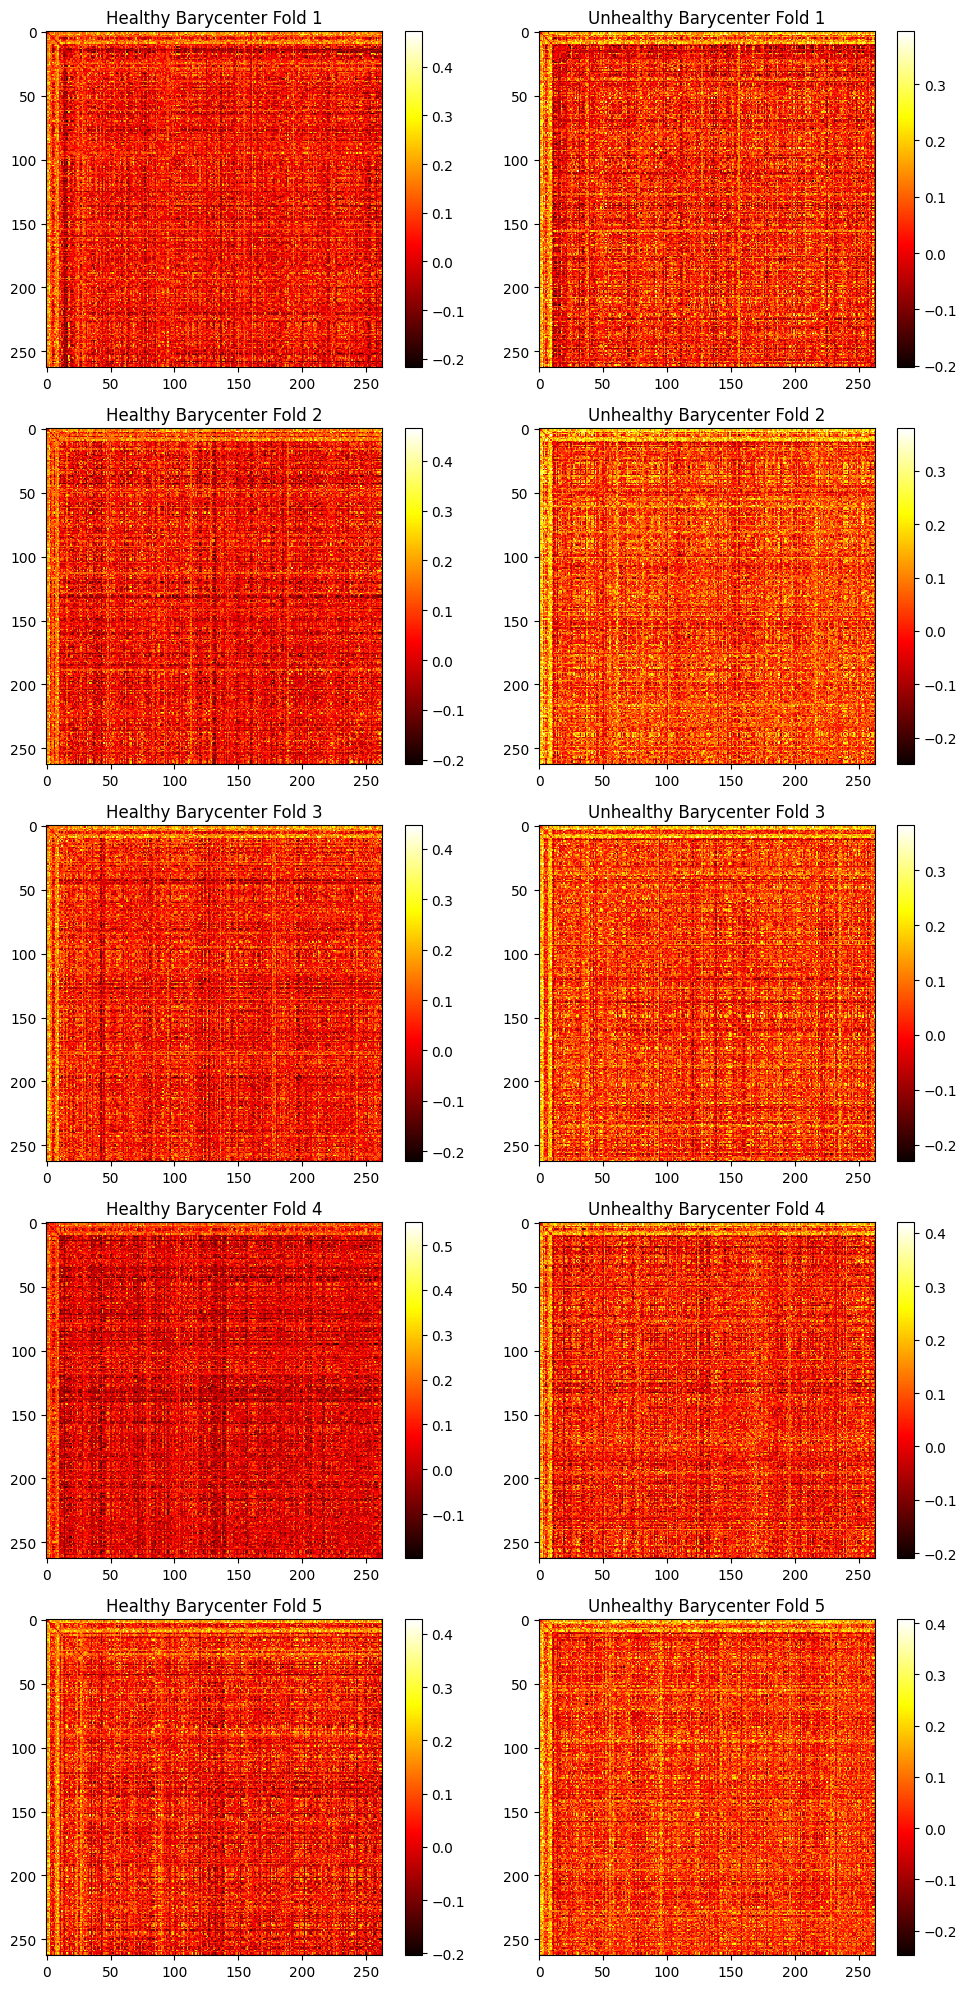

In [18]:
# Visualize the barycenters
fig, axs = plt.subplots(5, 2, figsize=(10, 20))  # Adjust the size as needed
for i, (healthy_bary, unhealthy_bary) in enumerate(zip(healthy_barys, unhealthy_barys)):
    # Plotting the healthy barycenter
    ax = axs[i, 0]
    cax = ax.imshow(healthy_bary, cmap='hot', interpolation='none')
    fig.colorbar(cax, ax=ax)
    ax.set_title(f'Healthy Barycenter Fold {i+1}')
    
    # Plotting the unhealthy barycenter
    ax = axs[i, 1]
    cax = ax.imshow(unhealthy_bary, cmap='hot', interpolation='none')
    fig.colorbar(cax, ax=ax)
    ax.set_title(f'Unhealthy Barycenter Fold {i+1}')
plt.tight_layout()
plt.show()

In [19]:
# Compute GW distances between barycenters
for i, (healthy_bary, unhealthy_bary) in enumerate(zip(healthy_barys, unhealthy_barys)):
    bary_dist, log_dist = ot.gromov.gromov_wasserstein(
    healthy_bary, unhealthy_bary, loss_fun='square_loss', log=True)
    print("Distance between barycenters:", log_dist['gw_dist'], f"Fold {i}")

Distance between barycenters: 0.004434874903310029 Fold 0
Distance between barycenters: 0.004576620097098374 Fold 1
Distance between barycenters: 0.004298026932532381 Fold 2
Distance between barycenters: 0.004414436744822154 Fold 3
Distance between barycenters: 0.004594669331966083 Fold 4


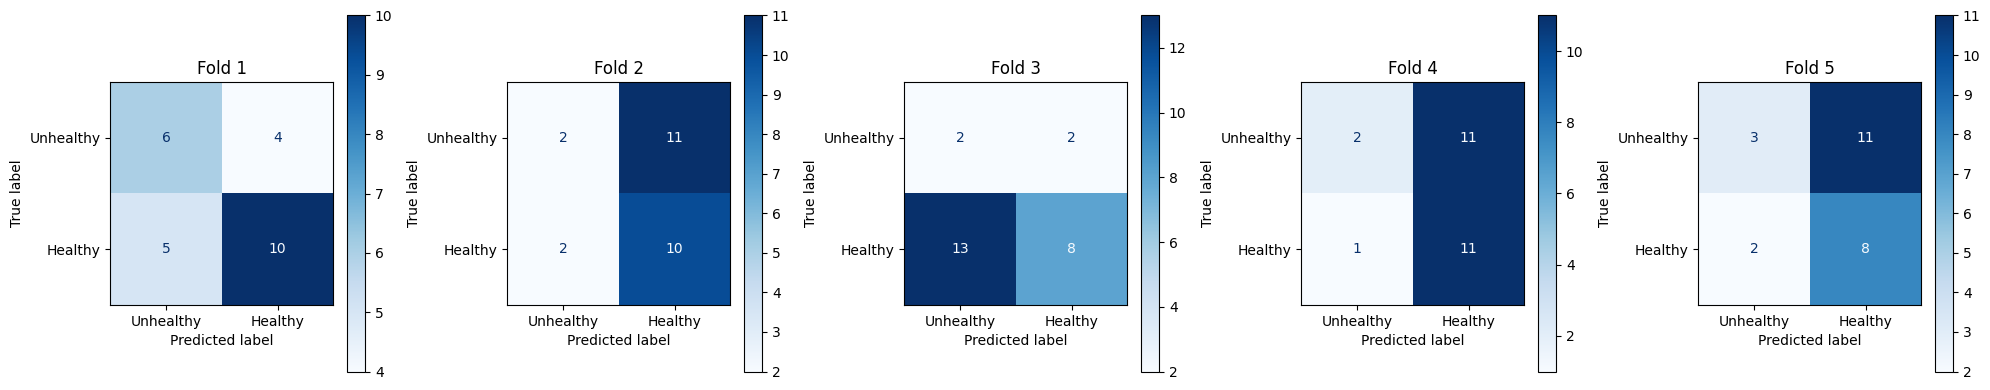

In [21]:
# Visualize the confusion matrices
fig, axs = plt.subplots(1, 5, figsize=(20, 4))  # Adjust the size as needed
for i, cm in enumerate(confusion_mats):
    ax = axs[i]
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unhealthy', 'Healthy'])
    display.plot(cmap='Blues', ax=ax)
    ax.set_title(f'Fold {i+1}')
plt.tight_layout()
plt.show()